# 데이터 분석 전처리 (Data Preprocessing)
데이터 분석 및 머신러닝에서 **전처리(Preprocessing)** 는 분석 결과의 품질을 좌우하는 가장 중요한 단계이다.
"Garbage In, Garbage Out" 이라는 말처럼 아무리 좋은 모델이라도 데이터가 깨끗하지 않으면 좋은 결과를 낼 수 없다.

## 전처리 과정의 일반적인 순서
1. 데이터 불러오기 및 탐색 (Load & Inspect)
2. 결측치 처리 (Missing Values)
3. 중복 데이터 처리 (Duplicates)
4. 이상치 탐지 및 처리 (Outliers)
5. 데이터 타입 변환 (Type Conversion)
6. 문자열 처리 (String Processing)
7. 날짜/시간 처리 (Datetime Processing)
8. 범주형 변수 인코딩 (Categorical Encoding)
9. 수치형 변수 스케일링 (Feature Scaling)
10. 비닝/구간화 (Binning)
11. 데이터 변환 (Log, Box-Cox 등)
12. 피처 엔지니어링 (Feature Engineering)
13. 데이터 병합 (Merge & Concat)
14. 그룹화 및 집계 (GroupBy)
15. 데이터 분할 (Train/Test Split)
16. 불균형 데이터 처리 (Imbalanced Data)
17. 파이프라인 구성 (sklearn Pipeline)


In [2]:
# 전처리에서 자주 사용하는 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 메시지 숨기기
import warnings
warnings.filterwarnings('ignore')

# 출력 옵션 설정
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)


# 1. 데이터 불러오기 및 탐색 (Load & Inspect)
데이터 분석의 첫 단계는 데이터를 불러와서 **전체적인 구조와 특징을 파악**하는 것이다.
- `read_csv()`, `read_excel()`, `read_json()` 등으로 데이터를 불러온다.
- `head()`, `tail()`, `info()`, `describe()` 등으로 데이터의 형태를 확인한다.


In [3]:
# 실습용 샘플 데이터 생성
np.random.seed(42)
df = pd.DataFrame({
    'id': range(1, 11),
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve',
             'Frank', 'Grace', 'Henry', 'Ivy', 'Jack'],
    'age': [25, 30, np.nan, 35, 28, 40, np.nan, 22, 33, 29],
    'salary': [50000, 60000, 75000, 80000, 55000,
               90000, 65000, 45000, 70000, 1000000],   # 마지막 값은 이상치
    'department': ['HR', 'IT', 'IT', 'Finance', 'HR',
                   'IT', 'Finance', 'HR', 'IT', 'Finance'],
    'join_date': ['2020-01-15', '2019-03-20', '2021-07-10', '2018-11-05',
                  '2022-02-28', '2017-06-15', '2020-09-12', '2023-01-08',
                  '2019-12-25', '2021-04-18']
})
df


,id,name,age,salary,department,join_date
0,1,Alice,25.0000,50000,HR,2020-01-15
1,2,Bob,30.0000,60000,IT,2019-03-20
2,3,Charlie,NaN,75000,IT,2021-07-10
3,4,David,35.0000,80000,Finance,2018-11-05
4,5,Eve,28.0000,55000,HR,2022-02-28
5,6,Frank,40.0000,90000,IT,2017-06-15
6,7,Grace,NaN,65000,Finance,2020-09-12
7,8,Henry,22.0000,45000,HR,2023-01-08
8,9,Ivy,33.0000,70000,IT,2019-12-25
9,10,Jack,29.0000,1000000,Finance,2021-04-18


In [4]:
# 데이터 기본 정보 확인
print('데이터 형태(shape):', df.shape)        # (행, 열)
print('컬럼명:', df.columns.tolist())
print('데이터 타입:')
print(df.dtypes)


데이터 형태(shape): (10, 6)
컬럼명: ['id', 'name', 'age', 'salary', 'department', 'join_date']
데이터 타입:
id              int64
name           object
age           float64
salary          int64
department     object
join_date      object
dtype: object


In [5]:
# info() - 전체 정보 (결측치 포함)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          10 non-null     int64  
 1   name        10 non-null     object 
 2   age         8 non-null      float64
 3   salary      10 non-null     int64  
 4   department  10 non-null     object 
 5   join_date   10 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 612.0+ bytes


In [6]:
# describe() - 수치형 변수 통계 요약
df.describe()


,id,age,salary
count,10.0000,8.0000,10.0000
mean,5.5000,30.2500,159000.0000
std,3.0277,5.7009,295820.8918
min,1.0000,22.0000,45000.0000
25%,3.2500,27.2500,56250.0000
50%,5.5000,29.5000,67500.0000
75%,7.7500,33.5000,78750.0000
max,10.0000,40.0000,1000000.0000


In [7]:
# describe(include='object') - 범주형 변수 요약
df.describe(include='object')


,name,department,join_date
count,10,10,10
unique,10,3,10
top,Alice,IT,2020-01-15
freq,1,4,1


In [8]:
# head() / tail() / sample() 활용
print('--- head(3) ---')
print(df.head(3))
print()
print('--- tail(2) ---')
print(df.tail(2))
print()
print('--- sample(2) (무작위 추출) ---')
print(df.sample(2, random_state=1))


--- head(3) ---
   id     name     age  salary department   join_date
0   1    Alice 25.0000   50000         HR  2020-01-15
1   2      Bob 30.0000   60000         IT  2019-03-20
2   3  Charlie     NaN   75000         IT  2021-07-10

--- tail(2) ---
   id  name     age   salary department   join_date
8   9   Ivy 33.0000    70000         IT  2019-12-25
9  10  Jack 29.0000  1000000    Finance  2021-04-18

--- sample(2) (무작위 추출) ---
   id     name     age   salary department   join_date
2   3  Charlie     NaN    75000         IT  2021-07-10
9  10     Jack 29.0000  1000000    Finance  2021-04-18


# 2. 결측치(Missing Values) 처리
실제 데이터에는 누락된 값(`NaN`, `None`, `NaT`)이 자주 등장한다. 결측치를 어떻게 처리하느냐에 따라 분석 결과가 크게 달라진다.

## 결측치 처리 방법
- **제거(Deletion)**: `dropna()`
- **대체(Imputation)**: `fillna()` (평균/중앙값/최빈값/특정 값)
- **보간(Interpolation)**: `interpolate()` (시계열 데이터에 적합)


In [9]:
# 결측치 확인
print('--- 컬럼별 결측치 개수 ---')
print(df.isnull().sum())

print('\n--- 컬럼별 결측치 비율(%) ---')
print((df.isnull().sum() / len(df) * 100).round(2))


--- 컬럼별 결측치 개수 ---
id            0
name          0
age           2
salary        0
department    0
join_date     0
dtype: int64

--- 컬럼별 결측치 비율(%) ---
id            0.0000
name          0.0000
age          20.0000
salary        0.0000
department    0.0000
join_date     0.0000
dtype: float64


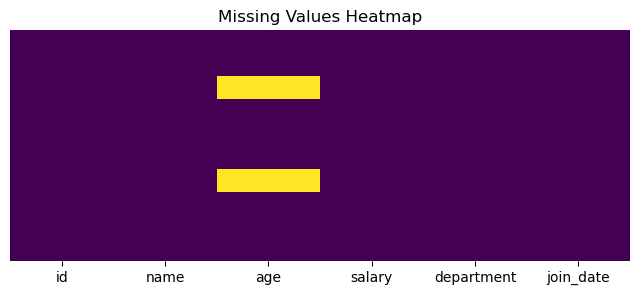

In [10]:
# 결측치 시각화 - 히트맵
plt.figure(figsize=(8, 3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()


In [11]:
# 방법 1) 결측치 제거 - dropna()
df_drop_row = df.dropna()                        # 결측치가 있는 행 전체 제거
df_drop_col = df.dropna(axis=1)                  # 결측치가 있는 열 전체 제거
df_drop_thresh = df.dropna(thresh=5)             # 결측치가 아닌 값이 5개 이상인 행만 유지
df_drop_subset = df.dropna(subset=['age'])       # 'age' 컬럼에만 결측치 제거 적용

print('원본:', df.shape, ' / 행 제거 후:', df_drop_row.shape)


원본: (10, 6)  / 행 제거 후: (8, 6)


In [12]:
# 방법 2) 결측치 대체 - fillna()
# 평균값으로 대체
df_mean = df.copy()
df_mean['age'] = df_mean['age'].fillna(df_mean['age'].mean())

# 중앙값으로 대체 (이상치에 강건함)
df_median = df.copy()
df_median['age'] = df_median['age'].fillna(df_median['age'].median())

# 최빈값으로 대체 (범주형 데이터에 적합)
df_mode = df.copy()
df_mode['age'] = df_mode['age'].fillna(df_mode['age'].mode()[0])

# 특정 값으로 대체
df_const = df.copy()
df_const['age'] = df_const['age'].fillna(0)

# 앞/뒤 값으로 대체 (ffill: forward fill, bfill: backward fill)
df_ffill = df.copy()
df_ffill['age'] = df_ffill['age'].ffill()
df_ffill['age'] = df_ffill['age'].bfill()  # ffill 후 남은 NaN 처리

print('평균 대체:', df_mean['age'].tolist())
print('중앙값 대체:', df_median['age'].tolist())


평균 대체: [25.0, 30.0, 30.25, 35.0, 28.0, 40.0, 30.25, 22.0, 33.0, 29.0]
중앙값 대체: [25.0, 30.0, 29.5, 35.0, 28.0, 40.0, 29.5, 22.0, 33.0, 29.0]


In [13]:
# 방법 3) 보간법 - interpolate() (특히 시계열에 유용)
s = pd.Series([1, 2, np.nan, np.nan, 5, 6, np.nan, 8])
print('선형 보간:', s.interpolate(method='linear').tolist())
print('다항식 보간:', s.interpolate(method='polynomial', order=2).tolist())


선형 보간: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
다항식 보간: [1.0, 2.0, 3.0, 3.999999999999999, 5.0, 6.0, 7.000000000000002, 8.0]


In [14]:
# 방법 4) 그룹별 평균으로 대체 (실무에서 자주 사용)
df_group = df.copy()
df_group['age'] = df_group.groupby('department')['age'].transform(
    lambda x: x.fillna(x.mean())
)
df_group


,id,name,age,salary,department,join_date
0,1,Alice,25.0000,50000,HR,2020-01-15
1,2,Bob,30.0000,60000,IT,2019-03-20
2,3,Charlie,34.3333,75000,IT,2021-07-10
3,4,David,35.0000,80000,Finance,2018-11-05
4,5,Eve,28.0000,55000,HR,2022-02-28
5,6,Frank,40.0000,90000,IT,2017-06-15
6,7,Grace,32.0000,65000,Finance,2020-09-12
7,8,Henry,22.0000,45000,HR,2023-01-08
8,9,Ivy,33.0000,70000,IT,2019-12-25
9,10,Jack,29.0000,1000000,Finance,2021-04-18


# 3. 중복 데이터(Duplicates) 처리
같은 행이 여러 번 들어가 있으면 통계량과 모델이 왜곡된다.
- `duplicated()`: 중복 여부를 Boolean으로 반환
- `drop_duplicates()`: 중복 행 제거


In [15]:
# 중복 데이터 생성
df_dup = pd.concat([df, df.iloc[[0, 1]]], ignore_index=True)
print('중복 포함 데이터 형태:', df_dup.shape)

# 중복 행 확인
print('\n중복 행 개수:', df_dup.duplicated().sum())
print('\n중복된 행:')
print(df_dup[df_dup.duplicated(keep=False)].sort_values('id'))


중복 포함 데이터 형태: (12, 6)

중복 행 개수: 2

중복된 행:
    id   name     age  salary department   join_date
0    1  Alice 25.0000   50000         HR  2020-01-15
10   1  Alice 25.0000   50000         HR  2020-01-15
1    2    Bob 30.0000   60000         IT  2019-03-20
11   2    Bob 30.0000   60000         IT  2019-03-20


In [16]:
# 중복 제거
df_unique = df_dup.drop_duplicates()
print('전체 중복 제거 후:', df_unique.shape)

# 특정 컬럼 기준으로 중복 제거
df_unique_dept = df_dup.drop_duplicates(subset=['department'], keep='first')
print('department 기준 중복 제거:', df_unique_dept.shape)

# keep 옵션:
#   'first' (기본) - 첫 번째 행 유지
#   'last'         - 마지막 행 유지
#   False          - 중복된 모든 행 제거


전체 중복 제거 후: (10, 6)
department 기준 중복 제거: (3, 6)


# 4. 이상치(Outliers) 탐지 및 처리
이상치는 다른 값들과 크게 동떨어진 값으로, 모델 성능과 통계량에 큰 영향을 미친다.

## 이상치 탐지 방법
- **IQR (사분위수 범위)**: `Q1 - 1.5*IQR ~ Q3 + 1.5*IQR` 범위를 벗어나는 값
- **Z-score**: 평균에서 표준편차의 ±3 이상 떨어진 값
- **시각적 탐지**: Boxplot, Scatter plot

## 이상치 처리 방법
- 제거(Removal)
- 캡핑(Capping / Winsorization): 임계값으로 대체
- 변환(Transformation): log, sqrt 등으로 분포 정규화


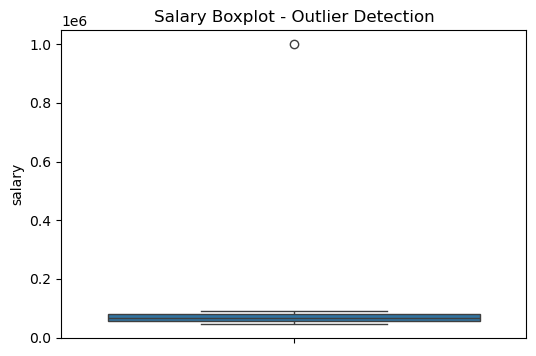

In [70]:
# Boxplot으로 이상치 시각화
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['salary'])
plt.title('Salary Boxplot - Outlier Detection')
plt.show()


In [18]:
# 방법 1) IQR 방식
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f'Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}')
print(f'정상 범위: {lower:.0f} ~ {upper:.0f}')

outliers = df[(df['salary'] < lower) | (df['salary'] > upper)]
print('\n이상치:')
print(outliers[['name', 'salary']])


Q1 = 56250.0, Q3 = 78750.0, IQR = 22500.0
정상 범위: 22500 ~ 112500

이상치:
   name   salary
9  Jack  1000000


In [19]:
# 방법 2) Z-score 방식
from scipy import stats

z_scores = np.abs(stats.zscore(df['salary']))
print('Z-score:', z_scores.round(2))

# Z-score가 3 이상이면 이상치로 판정 (보통 2 또는 3 사용)
outliers_z = df[z_scores > 2]
print('\nZ-score > 2 이상치:')
print(outliers_z[['name', 'salary']])


Z-score: [0.39 0.35 0.3  0.28 0.37 0.25 0.33 0.41 0.32 3.  ]

Z-score > 2 이상치:
   name   salary
9  Jack  1000000


In [20]:
# 이상치 처리 1) 제거
df_no_outlier = df[(df['salary'] >= lower) & (df['salary'] <= upper)]
print('제거 후 형태:', df_no_outlier.shape)


제거 후 형태: (9, 6)


In [21]:
# 이상치 처리 2) 캡핑 (Winsorization) - 임계값으로 대체
df_capped = df.copy()
df_capped['salary'] = df_capped['salary'].clip(lower=lower, upper=upper)
print('캡핑 후 salary:')
print(df_capped[['name', 'salary']])


캡핑 후 salary:
      name  salary
0    Alice   50000
1      Bob   60000
2  Charlie   75000
3    David   80000
4      Eve   55000
5    Frank   90000
6    Grace   65000
7    Henry   45000
8      Ivy   70000
9     Jack  112500


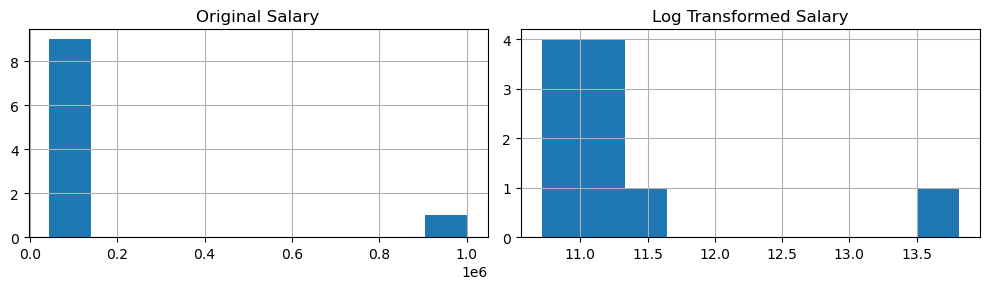

In [22]:
# 이상치 처리 3) 로그 변환 - 분포의 왜도(skewness)를 줄임
df_log = df.copy()
df_log['salary_log'] = np.log1p(df_log['salary'])  # log(1+x) 사용 (0값 처리 가능)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
df['salary'].hist(ax=axes[0], bins=10)
axes[0].set_title('Original Salary')
df_log['salary_log'].hist(ax=axes[1], bins=10)
axes[1].set_title('Log Transformed Salary')
plt.tight_layout()
plt.show()


# 5. 데이터 타입 변환 (Type Conversion)
데이터 타입이 잘못되어 있으면 연산이 안 되거나 메모리 낭비가 발생한다.
- `astype()`: 일반적인 타입 변환
- `pd.to_numeric()`: 숫자형으로 변환 (오류 처리 옵션 제공)
- `pd.to_datetime()`: 날짜형으로 변환
- `pd.Categorical()`: 메모리 효율적인 범주형으로 변환


In [71]:
# 타입 변환 예시 데이터
df_type = pd.DataFrame({
    'price': ['100', '200', '300', '400'],         # 문자열 -> 숫자
    'quantity': [1.0, 2.0, 3.0, 4.0],              # float -> int
    'date': ['2024-01-01', '2024-02-15', '2024-03-30', '2024-04-10'], # 문자열 -> datetime
    'category': ['A', 'B', 'A', 'C']               # object -> category
})
print('변환 전 dtypes:')
print(df_type.dtypes)


변환 전 dtypes:
price        object
quantity    float64
date         object
category     object
dtype: object


In [24]:
# astype()로 타입 변환
df_type['price'] = df_type['price'].astype(int)
df_type['quantity'] = df_type['quantity'].astype(int)
df_type['date'] = pd.to_datetime(df_type['date'])
df_type['category'] = df_type['category'].astype('category')

print('변환 후 dtypes:')
print(df_type.dtypes)


변환 후 dtypes:
price                int64
quantity             int64
date        datetime64[ns]
category          category
dtype: object


In [25]:
# pd.to_numeric()의 errors 옵션
s = pd.Series(['1', '2', 'abc', '4'])

# errors='raise' (기본): 오류 발생
# errors='coerce': 변환 실패 시 NaN으로 대체 (실무에서 유용)
# errors='ignore': 변환 실패 시 원본 그대로 유지
print(pd.to_numeric(s, errors='coerce').tolist())


[1.0, 2.0, nan, 4.0]


In [26]:
# 메모리 절약 팁: 큰 정수형 -> 작은 정수형으로 다운캐스트
df_big = pd.DataFrame({'a': range(1000)})
print('변환 전 메모리:', df_big.memory_usage(deep=True).sum(), 'bytes')

df_big['a'] = pd.to_numeric(df_big['a'], downcast='integer')
print('변환 후 메모리:', df_big.memory_usage(deep=True).sum(), 'bytes')
print('타입:', df_big['a'].dtype)


변환 전 메모리: 8132 bytes
변환 후 메모리: 2132 bytes
타입: int16


# 6. 문자열 처리 (String Processing)
텍스트 데이터를 다룰 때는 `.str` 접근자를 사용해서 벡터화된 연산을 할 수 있다.
- `str.lower()`, `str.upper()`, `str.strip()`: 대소문자/공백 처리
- `str.replace()`, `str.contains()`, `str.split()`: 치환/검색/분할
- 정규표현식(regex)도 지원


In [27]:
# 문자열 처리 예시 데이터
df_str = pd.DataFrame({
    'email': ['  Alice@Gmail.com ', 'BOB@yahoo.com', 'charlie@naver.com'],
    'phone': ['010-1234-5678', '010.2222.3333', '010 4444 5555'],
    'address': ['Seoul, Gangnam-gu', 'Busan, Haeundae-gu', 'Incheon, Yeonsu-gu']
})
df_str


,email,phone,address
0,Alice@Gmail.com,010-1234-5678,"Seoul, Gangnam-gu"
1,BOB@yahoo.com,010.2222.3333,"Busan, Haeundae-gu"
2,charlie@naver.com,010 4444 5555,"Incheon, Yeonsu-gu"


In [28]:
# 기본 문자열 처리
df_str['email_clean'] = df_str['email'].str.strip().str.lower()
print(df_str[['email', 'email_clean']])


                email        email_clean
0    Alice@Gmail.com     alice@gmail.com
1       BOB@yahoo.com      bob@yahoo.com
2   charlie@naver.com  charlie@naver.com


In [29]:
# 분할 - str.split()
df_str['city'] = df_str['address'].str.split(',').str[0]
df_str['district'] = df_str['address'].str.split(',').str[1].str.strip()
df_str[['address', 'city', 'district']]


,address,city,district
0,"Seoul, Gangnam-gu",Seoul,Gangnam-gu
1,"Busan, Haeundae-gu",Busan,Haeundae-gu
2,"Incheon, Yeonsu-gu",Incheon,Yeonsu-gu


In [ ]:
# 치환 + 정규표현식 - 전화번호 통일
df_str['phone_clean'] = df_str['phone'].str.replace(r'[.\s]', '-', regex=True)
df_str[['phone', 'phone_clean']]


,phone,phone_clean
0,010-1234-5678,010-1234-5678
1,010.2222.3333,010-2222-3333
2,010 4444 5555,010-4444-5555


In [31]:
# 포함 여부 검색 - str.contains()
df_str['is_gmail'] = df_str['email_clean'].str.contains('gmail', case=False)

# 정규표현식으로 도메인 추출 - str.extract()
df_str['domain'] = df_str['email_clean'].str.extract(r'@(.+)$')
df_str[['email_clean', 'is_gmail', 'domain']]


,email_clean,is_gmail,domain
0,alice@gmail.com,True,gmail.com
1,bob@yahoo.com,False,yahoo.com
2,charlie@naver.com,False,naver.com


# 7. 날짜/시간 처리 (Datetime Processing)
시계열 데이터에서는 날짜 컬럼에서 다양한 특성을 추출하는 것이 매우 중요하다.
- `pd.to_datetime()`: 문자열 -> datetime 변환
- `.dt` 접근자: year, month, day, dayofweek, hour 등 추출


In [32]:
# 날짜 컬럼 변환
df['join_date'] = pd.to_datetime(df['join_date'])
print(df['join_date'].dtype)
df.head(3)


datetime64[ns]


,id,name,age,salary,department,join_date
0,1,Alice,25.0000,50000,HR,2020-01-15
1,2,Bob,30.0000,60000,IT,2019-03-20
2,3,Charlie,NaN,75000,IT,2021-07-10


In [33]:
# .dt 접근자로 시간 특성 추출
df['year'] = df['join_date'].dt.year
df['month'] = df['join_date'].dt.month
df['day'] = df['join_date'].dt.day
df['dayofweek'] = df['join_date'].dt.dayofweek          # 월=0, 일=6
df['day_name'] = df['join_date'].dt.day_name()
df['quarter'] = df['join_date'].dt.quarter
df['is_weekend'] = df['dayofweek'].isin([5, 6])

df[['join_date', 'year', 'month', 'day_name', 'quarter', 'is_weekend']].head()


,join_date,year,month,day_name,quarter,is_weekend
0,2020-01-15,2020,1,Wednesday,1,False
1,2019-03-20,2019,3,Wednesday,1,False
2,2021-07-10,2021,7,Saturday,3,True
3,2018-11-05,2018,11,Monday,4,False
4,2022-02-28,2022,2,Monday,1,False


In [34]:
# 날짜 차이 계산 - 입사 후 근속 일수
today = pd.Timestamp('2024-01-01')
df['days_employed'] = (today - df['join_date']).dt.days
df['years_employed'] = df['days_employed'] / 365.25

df[['name', 'join_date', 'days_employed', 'years_employed']].head()


,name,join_date,days_employed,years_employed
0,Alice,2020-01-15,1447,3.9617
1,Bob,2019-03-20,1748,4.7858
2,Charlie,2021-07-10,905,2.4778
3,David,2018-11-05,1883,5.1554
4,Eve,2022-02-28,672,1.8398


In [35]:
# 날짜 범위로 필터링
mask = (df['join_date'] >= '2020-01-01') & (df['join_date'] <= '2022-12-31')
df_filtered = df[mask]
print('2020~2022년 입사자 수:', len(df_filtered))


2020~2022년 입사자 수: 5


# 8. 범주형 변수 인코딩 (Categorical Encoding)
머신러닝 모델은 대부분 숫자만 입력으로 받기 때문에, 범주형(문자열) 데이터를 숫자로 변환해야 한다.

## 주요 인코딩 방법
| 방법 | 설명 | 사용 시점 |
| --- | --- | --- |
| **Label Encoding** | 각 카테고리에 정수 부여 (A=0, B=1) | 순서 의미가 있을 때, 트리 모델 |
| **One-Hot Encoding** | 각 카테고리를 0/1 컬럼으로 분리 | 순서 없는 명목형, 선형 모델 |
| **Ordinal Encoding** | 명시적인 순서 부여 (Low<Mid<High) | 명확한 순서가 있을 때 |


In [36]:
# Label Encoding - sklearn
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()
le = LabelEncoder()
df_enc['dept_label'] = le.fit_transform(df_enc['department'])

print('매핑:', dict(zip(le.classes_, le.transform(le.classes_))))
df_enc[['department', 'dept_label']].head()


매핑: {'Finance': np.int64(0), 'HR': np.int64(1), 'IT': np.int64(2)}


,department,dept_label
0,HR,1
1,IT,2
2,IT,2
3,Finance,0
4,HR,1


In [37]:
# One-Hot Encoding - pandas의 get_dummies()
df_onehot = pd.get_dummies(df, columns=['department'], prefix='dept')
df_onehot.head()


,id,name,age,salary,join_date,year,month,day,dayofweek,day_name,quarter,is_weekend,days_employed,years_employed,dept_Finance,dept_HR,dept_IT
0,1,Alice,25.0000,50000,2020-01-15,2020,1,15,2,Wednesday,1,False,1447,3.9617,False,True,False
1,2,Bob,30.0000,60000,2019-03-20,2019,3,20,2,Wednesday,1,False,1748,4.7858,False,False,True
2,3,Charlie,NaN,75000,2021-07-10,2021,7,10,5,Saturday,3,True,905,2.4778,False,False,True
3,4,David,35.0000,80000,2018-11-05,2018,11,5,0,Monday,4,False,1883,5.1554,True,False,False
4,5,Eve,28.0000,55000,2022-02-28,2022,2,28,0,Monday,1,False,672,1.8398,False,True,False


In [38]:
# One-Hot Encoding - drop_first=True (다중공선성 방지)
# n개의 카테고리를 (n-1)개의 컬럼으로 표현
df_onehot2 = pd.get_dummies(df, columns=['department'], prefix='dept', drop_first=True)
df_onehot2.head()


,id,name,age,salary,join_date,year,month,day,dayofweek,day_name,quarter,is_weekend,days_employed,years_employed,dept_HR,dept_IT
0,1,Alice,25.0000,50000,2020-01-15,2020,1,15,2,Wednesday,1,False,1447,3.9617,True,False
1,2,Bob,30.0000,60000,2019-03-20,2019,3,20,2,Wednesday,1,False,1748,4.7858,False,True
2,3,Charlie,NaN,75000,2021-07-10,2021,7,10,5,Saturday,3,True,905,2.4778,False,True
3,4,David,35.0000,80000,2018-11-05,2018,11,5,0,Monday,4,False,1883,5.1554,False,False
4,5,Eve,28.0000,55000,2022-02-28,2022,2,28,0,Monday,1,False,672,1.8398,True,False


In [39]:
# Ordinal Encoding - 명시적인 순서 지정
from sklearn.preprocessing import OrdinalEncoder

df_ord = pd.DataFrame({'size': ['Small', 'Large', 'Medium', 'Small', 'Large']})

oe = OrdinalEncoder(categories=[['Small', 'Medium', 'Large']])
df_ord['size_encoded'] = oe.fit_transform(df_ord[['size']])
df_ord


,size,size_encoded
0,Small,0.0000
1,Large,2.0000
2,Medium,1.0000
3,Small,0.0000
4,Large,2.0000


In [40]:
# map() 함수로 직접 매핑 (간단한 경우)
size_map = {'Small': 1, 'Medium': 2, 'Large': 3}
df_ord['size_map'] = df_ord['size'].map(size_map)
df_ord


,size,size_encoded,size_map
0,Small,0.0000,1
1,Large,2.0000,3
2,Medium,1.0000,2
3,Small,0.0000,1
4,Large,2.0000,3


# 9. 수치형 변수 스케일링 (Feature Scaling)
변수 간 단위(scale)가 크게 다르면(예: 키 cm vs 연봉 원), 거리 기반 알고리즘(KNN, SVM)이나 경사하강법 기반 모델(선형 회귀, 신경망)이 한쪽 변수에 치우치게 된다.

## 주요 스케일링 방법
| 스케일러 | 공식 | 특징 |
| --- | --- | --- |
| **StandardScaler** | (x - μ) / σ | 평균 0, 표준편차 1 (정규분포 가정) |
| **MinMaxScaler** | (x - min) / (max - min) | 0~1 범위로 압축 |
| **RobustScaler** | (x - median) / IQR | 중앙값/IQR 사용, 이상치에 강건 |
| **MaxAbsScaler** | x / |max| | -1~1 범위 (희소 데이터에 적합) |


In [41]:
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
)

# 스케일링 대상
df_scale = df[['age', 'salary']].dropna().reset_index(drop=True)

scalers = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler(),
    'MaxAbs': MaxAbsScaler()
}

results = {'Original': df_scale.copy()}
for name, scaler in scalers.items():
    scaled = scaler.fit_transform(df_scale)
    results[name] = pd.DataFrame(scaled, columns=df_scale.columns)

# 비교
for name, data in results.items():
    print(f'--- {name} ---')
    print(data.describe().loc[['mean', 'std', 'min', 'max']].round(3))
    print()


--- Original ---
         age       salary
mean 30.2500  181250.0000
std   5.7010  331174.8570
min  22.0000   45000.0000
max  40.0000 1000000.0000

--- Standard ---
         age  salary
mean  0.0000  0.0000
std   1.0690  1.0690
min  -1.5470 -0.4400
max   1.8280  2.6430

--- MinMax ---
        age  salary
mean 0.4580  0.1430
std  0.3170  0.3470
min  0.0000  0.0000
max  1.0000  1.0000

--- Robust ---
         age  salary
mean  0.1200  4.0430
std   0.9120 11.5190
min  -1.2000 -0.6960
max   1.6800 32.5220

--- MaxAbs ---
        age  salary
mean 0.7560  0.1810
std  0.1430  0.3310
min  0.5500  0.0450
max  1.0000  1.0000



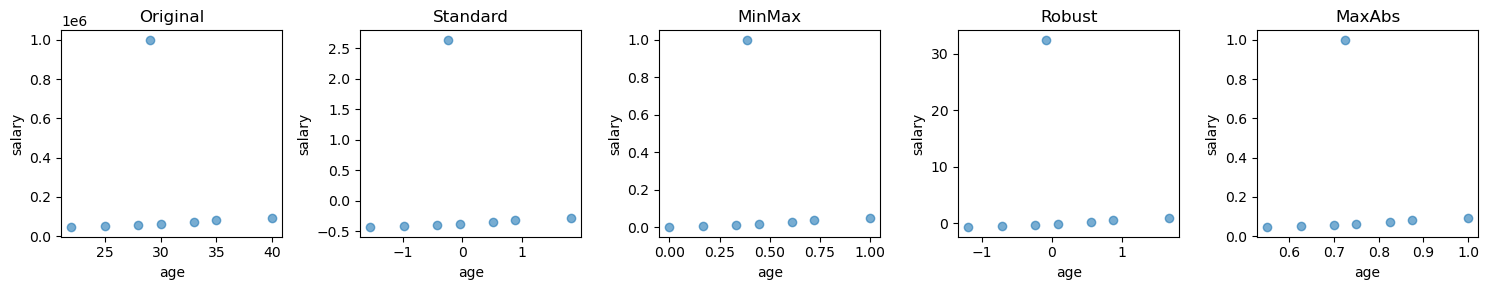

In [42]:
# 시각화 비교
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (name, data) in zip(axes, results.items()):
    ax.scatter(data['age'], data['salary'], alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel('age')
    ax.set_ylabel('salary')
plt.tight_layout()
plt.show()


## 스케일링 사용 시 주의사항
1. **fit은 train 데이터에만, transform은 train/test 모두에 적용**해야 한다 (data leakage 방지).
2. 트리 기반 모델(Decision Tree, Random Forest, XGBoost 등)은 스케일링이 **불필요**하다.
3. 이상치가 많은 데이터에는 RobustScaler가 유리하다.


In [43]:
# 올바른 스케일링 패턴 (data leakage 방지)
from sklearn.model_selection import train_test_split

X = df_scale[['age']]
y = df_scale['salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # train에서만 fit
X_test_scaled = scaler.transform(X_test)         # test에는 transform만

print('train mean:', X_train_scaled.mean().round(3),
      ' / std:', X_train_scaled.std().round(3))
print('test mean :', X_test_scaled.mean().round(3),
      ' / std:', X_test_scaled.std().round(3))


train mean: 0.0  / std: 1.0
test mean : -1.691  / std: 0.761


# 10. 비닝/구간화 (Binning)
연속형 변수를 구간(bin)으로 나눠 범주형으로 만드는 기법이다.
- 비선형 관계 표현
- 이상치의 영향 감소
- 해석력(interpretability) 향상

## pandas의 두 가지 비닝 함수
- `pd.cut()`: **값의 범위**를 기준으로 동일한 너비로 분할
- `pd.qcut()`: **개수**를 기준으로 동일한 빈도로 분할 (분위수 기반)


In [44]:
# pd.cut() - 동일 너비 비닝
df_bin = df.dropna(subset=['age']).copy()
df_bin['age_group'] = pd.cut(df_bin['age'],
                              bins=[0, 25, 35, 45, 100],
                              labels=['Young', 'Adult', 'Middle', 'Senior'])
df_bin[['name', 'age', 'age_group']].head()


,name,age,age_group
0,Alice,25.0000,Young
1,Bob,30.0000,Adult
3,David,35.0000,Adult
4,Eve,28.0000,Adult
5,Frank,40.0000,Middle


In [45]:
# pd.qcut() - 동일 빈도 비닝 (4분위수)
df_bin['salary_quartile'] = pd.qcut(df_bin['salary'],
                                     q=4,
                                     labels=['Q1', 'Q2', 'Q3', 'Q4'])
print(df_bin['salary_quartile'].value_counts())
df_bin[['name', 'salary', 'salary_quartile']].head()


salary_quartile
Q1    2
Q2    2
Q3    2
Q4    2
Name: count, dtype: int64


,name,salary,salary_quartile
0,Alice,50000,Q1
1,Bob,60000,Q2
3,David,80000,Q3
4,Eve,55000,Q2
5,Frank,90000,Q4


# 11. 데이터 변환 (Transformation)
데이터의 분포가 한쪽으로 치우쳐(skewed) 있으면 모델 성능이 떨어진다.
변환 기법으로 **분포를 정규분포에 가깝게** 만들 수 있다.

## 주요 변환 기법
- **Log 변환**: 오른쪽 꼬리(right-skewed) 데이터에 효과적
- **Square root 변환**: 약하게 치우친 데이터에
- **Box-Cox 변환**: 양수 데이터에만 적용 가능
- **Yeo-Johnson 변환**: 음수도 처리 가능


In [46]:
# 왜도(skewness) 확인
right_skewed = np.random.exponential(2, 1000)
print('원본 왜도:', pd.Series(right_skewed).skew().round(3))
print('Log 변환 후 왜도:', pd.Series(np.log1p(right_skewed)).skew().round(3))
print('Sqrt 변환 후 왜도:', pd.Series(np.sqrt(right_skewed)).skew().round(3))


원본 왜도: 1.868
Log 변환 후 왜도: 0.429
Sqrt 변환 후 왜도: 0.599


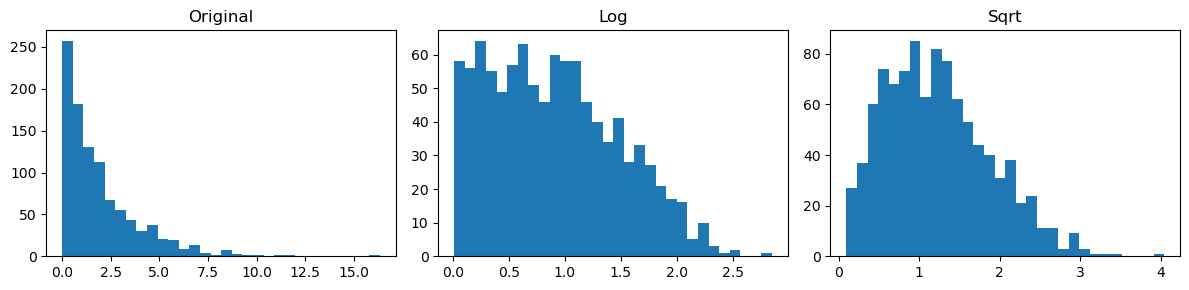

In [47]:
# 시각화로 변환 효과 확인
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(right_skewed, bins=30); axes[0].set_title('Original')
axes[1].hist(np.log1p(right_skewed), bins=30); axes[1].set_title('Log')
axes[2].hist(np.sqrt(right_skewed), bins=30); axes[2].set_title('Sqrt')
plt.tight_layout(); plt.show()


In [48]:
# Box-Cox & Yeo-Johnson 변환 (sklearn)
from sklearn.preprocessing import PowerTransformer

data = right_skewed.reshape(-1, 1)

# Box-Cox: 양수만 가능
pt_box = PowerTransformer(method='box-cox')
data_box = pt_box.fit_transform(data)

# Yeo-Johnson: 음수 가능
pt_yeo = PowerTransformer(method='yeo-johnson')
data_yeo = pt_yeo.fit_transform(data)

print('Box-Cox 후 왜도   :', pd.Series(data_box.flatten()).skew().round(3))
print('Yeo-Johnson 후 왜도:', pd.Series(data_yeo.flatten()).skew().round(3))


Box-Cox 후 왜도   : -0.055
Yeo-Johnson 후 왜도: 0.069


# 12. 피처 엔지니어링 (Feature Engineering)
도메인 지식을 바탕으로 **기존 변수에서 새로운 변수를 만들어내는** 작업이다.
모델 성능에 가장 큰 영향을 주는 단계 중 하나다.

## 자주 쓰이는 기법
- 사칙연산을 통한 파생 변수 (BMI = 체중 / 키²)
- 비율 변수 (가격/면적 = 평당 가격)
- 그룹 통계량 (해당 부서 평균 연봉 대비 비율)
- 다항식 피처 (x, x², x*y)
- 상호작용 변수


In [49]:
# 파생 변수 만들기
df_fe = df.copy()
df_fe['salary_per_year'] = df_fe['salary'] / df_fe['days_employed'] * 365

# 그룹 통계량을 피처로
df_fe['dept_avg_salary'] = df_fe.groupby('department')['salary'].transform('mean')
df_fe['salary_vs_dept'] = df_fe['salary'] / df_fe['dept_avg_salary']

df_fe[['name', 'department', 'salary', 'dept_avg_salary', 'salary_vs_dept']].head()


,name,department,salary,dept_avg_salary,salary_vs_dept
0,Alice,HR,50000,50000.0000,1.0000
1,Bob,IT,60000,73750.0000,0.8136
2,Charlie,IT,75000,73750.0000,1.0169
3,David,Finance,80000,381666.6667,0.2096
4,Eve,HR,55000,50000.0000,1.1000


In [50]:
# 다항식 피처 - PolynomialFeatures
from sklearn.preprocessing import PolynomialFeatures

X = np.array([[1, 2], [3, 4], [5, 6]])

# degree=2 -> 1, x1, x2, x1², x1*x2, x2²
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

print('변환 전:\n', X)
print('변환 후:\n', X_poly)
print('피처 이름:', poly.get_feature_names_out(['x1', 'x2']))


변환 전:
 [[1 2]
 [3 4]
 [5 6]]
변환 후:
 [[ 1.  2.  1.  2.  4.]
 [ 3.  4.  9. 12. 16.]
 [ 5.  6. 25. 30. 36.]]
피처 이름: ['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']


In [51]:
# 상호작용(interaction) 변수만 만들기
poly_inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_inter = poly_inter.fit_transform(X)
print('상호작용만:', poly_inter.get_feature_names_out(['x1', 'x2']))
print(X_inter)


상호작용만: ['x1' 'x2' 'x1 x2']
[[ 1.  2.  2.]
 [ 3.  4. 12.]
 [ 5.  6. 30.]]


# 13. 데이터 병합 (Merge & Concat)
여러 데이터 소스를 합치는 작업도 전처리의 중요한 부분이다.

| 함수 | 용도 | 비고 |
| --- | --- | --- |
| `pd.concat()` | 행/열 방향으로 단순 결합 | DB의 UNION과 유사 |
| `pd.merge()` | 키 컬럼 기준으로 결합 | DB의 JOIN과 유사 |
| `df.join()` | 인덱스 기준으로 결합 | merge의 단순한 형태 |


In [52]:
# 두 개의 데이터프레임 준비
employees = pd.DataFrame({
    'emp_id': [1, 2, 3, 4],
    'name': ['Alice', 'Bob', 'Charlie', 'David'],
    'dept_id': [10, 20, 10, 30]
})

departments = pd.DataFrame({
    'dept_id': [10, 20, 40],
    'dept_name': ['HR', 'IT', 'Marketing']
})
print(employees)
print()
print(departments)


   emp_id     name  dept_id
0       1    Alice       10
1       2      Bob       20
2       3  Charlie       10
3       4    David       30

   dept_id  dept_name
0       10         HR
1       20         IT
2       40  Marketing


In [53]:
# merge() - 4가지 join 방식
inner = pd.merge(employees, departments, on='dept_id', how='inner')   # 교집합
left  = pd.merge(employees, departments, on='dept_id', how='left')    # 왼쪽 기준
right = pd.merge(employees, departments, on='dept_id', how='right')   # 오른쪽 기준
outer = pd.merge(employees, departments, on='dept_id', how='outer')   # 합집합

print('--- INNER ---'); print(inner)
print('\n--- LEFT ---'); print(left)
print('\n--- OUTER ---'); print(outer)


--- INNER ---
   emp_id     name  dept_id dept_name
0       1    Alice       10        HR
1       2      Bob       20        IT
2       3  Charlie       10        HR

--- LEFT ---
   emp_id     name  dept_id dept_name
0       1    Alice       10        HR
1       2      Bob       20        IT
2       3  Charlie       10        HR
3       4    David       30       NaN

--- OUTER ---
   emp_id     name  dept_id  dept_name
0  1.0000    Alice       10         HR
1  3.0000  Charlie       10         HR
2  2.0000      Bob       20         IT
3  4.0000    David       30        NaN
4     NaN      NaN       40  Marketing


In [54]:
# concat() - 행 방향으로 이어붙이기
df_a = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df_b = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})

print('--- 행 방향 ---')
print(pd.concat([df_a, df_b], axis=0, ignore_index=True))

print('\n--- 열 방향 ---')
print(pd.concat([df_a, df_b], axis=1))


--- 행 방향 ---
   A  B
0  1  3
1  2  4
2  5  7
3  6  8

--- 열 방향 ---
   A  B  A  B
0  1  3  5  7
1  2  4  6  8


# 14. 그룹화 및 집계 (GroupBy & Aggregation)
그룹별 통계를 계산하는 것은 데이터 분석의 핵심이다.
- `groupby()`: 그룹화
- `agg()`: 여러 집계함수 동시 적용
- `transform()`: 그룹별 통계를 원본 행 수만큼 broadcast
- `pivot_table()`: 엑셀 피벗 테이블처럼 요약


In [55]:
# 단일 집계
df.groupby('department')['salary'].mean()


department
Finance   381666.6667
HR         50000.0000
IT         73750.0000
Name: salary, dtype: float64

In [56]:
# 여러 집계함수 동시 적용 - agg()
df.groupby('department').agg({
    'salary': ['mean', 'std', 'min', 'max'],
    'age': 'mean'
}).round(2)


salary                                 age
                  mean         std    min      max    mean
department                                                
Finance    381666.6700 535544.8900  65000  1000000 32.0000
HR          50000.0000   5000.0000  45000    55000 25.0000
IT          73750.0000  12500.0000  60000    90000 34.3300

In [57]:
# 사용자 정의 집계함수
def salary_range(x):
    return x.max() - x.min()

df.groupby('department').agg(
    avg_salary=('salary', 'mean'),
    salary_range=('salary', salary_range),
    count=('name', 'count')
)


,avg_salary,salary_range,count
department,,,
Finance,381666.6667,935000,3
HR,50000.0000,10000,3
IT,73750.0000,30000,4


In [58]:
# transform() - 그룹별 통계를 원본 행 수만큼 확장
df['dept_mean_salary'] = df.groupby('department')['salary'].transform('mean')
df['salary_diff'] = df['salary'] - df['dept_mean_salary']
df[['name', 'department', 'salary', 'dept_mean_salary', 'salary_diff']]


,name,department,salary,dept_mean_salary,salary_diff
0,Alice,HR,50000,50000.0000,0.0000
1,Bob,IT,60000,73750.0000,-13750.0000
2,Charlie,IT,75000,73750.0000,1250.0000
3,David,Finance,80000,381666.6667,-301666.6667
4,Eve,HR,55000,50000.0000,5000.0000
5,Frank,IT,90000,73750.0000,16250.0000
6,Grace,Finance,65000,381666.6667,-316666.6667
7,Henry,HR,45000,50000.0000,-5000.0000
8,Ivy,IT,70000,73750.0000,-3750.0000
9,Jack,Finance,1000000,381666.6667,618333.3333


In [59]:
# pivot_table() - 다차원 요약
df['hire_year'] = df['join_date'].dt.year
pivot = df.pivot_table(values='salary',
                        index='department',
                        columns='hire_year',
                        aggfunc='mean',
                        fill_value=0)
pivot.round(0)


hire_year,2017,2018,2019,2020,2021,2022,2023
department,,,,,,,
Finance,0.0000,80000.0000,0.0000,65000.0000,1000000.0000,0.0000,0.0000
HR,0.0000,0.0000,0.0000,50000.0000,0.0000,55000.0000,45000.0000
IT,90000.0000,0.0000,65000.0000,0.0000,75000.0000,0.0000,0.0000


# 15. 데이터 분할 (Train/Test Split)
모델의 일반화 성능을 평가하기 위해 학습용과 테스트용으로 데이터를 나눈다.
- `train_test_split()`: 무작위 분할
- `stratify` 옵션: 클래스 비율을 유지하며 분할 (분류 문제에서 필수)
- K-Fold 교차검증: 더 신뢰할 수 있는 평가 방법


In [60]:
from sklearn.model_selection import train_test_split

# 일반적인 분할
X = df[['age', 'salary']].fillna(0)
y = df['department']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,           # 30%를 테스트로
    random_state=42,         # 재현성을 위해 고정
    stratify=y               # 클래스 비율 유지 (분류문제)
)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'\ny_train 분포:\n{y_train.value_counts(normalize=True).round(2)}')
print(f'\ny_test 분포:\n{y_test.value_counts(normalize=True).round(2)}')


X_train: (7, 2), X_test: (3, 2)

y_train 분포:
department
IT        0.4300
Finance   0.2900
HR        0.2900
Name: proportion, dtype: float64

y_test 분포:
department
IT        0.3300
HR        0.3300
Finance   0.3300
Name: proportion, dtype: float64


In [61]:
# K-Fold 교차검증
from sklearn.model_selection import KFold, StratifiedKFold

# 일반 K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    print(f'Fold {i}: train={len(train_idx)}, val={len(val_idx)}')


Fold 1: train=8, val=2
Fold 2: train=8, val=2
Fold 3: train=8, val=2
Fold 4: train=8, val=2
Fold 5: train=8, val=2


# 16. 불균형 데이터 처리 (Imbalanced Data)
분류 문제에서 한 클래스가 다른 클래스보다 압도적으로 많을 때 모델은 다수 클래스만 예측하려 한다.
(예: 사기 탐지, 희귀병 진단)

## 처리 방법
- **언더샘플링(Undersampling)**: 다수 클래스 줄이기
- **오버샘플링(Oversampling)**: 소수 클래스 늘리기 (단순 복제 / SMOTE)
- **클래스 가중치(Class weight)**: 모델 학습 시 가중치 부여


In [62]:
# 불균형 데이터 생성
from sklearn.datasets import make_classification

X_imb, y_imb = make_classification(
    n_samples=1000, n_features=4,
    n_informative=3, n_redundant=1,
    n_classes=2,
    weights=[0.95, 0.05],     # 95:5 불균형
    random_state=42
)
print('클래스 분포:', pd.Series(y_imb).value_counts().to_dict())


클래스 분포: {0: 947, 1: 53}


In [63]:
# imblearn 패키지 사용 (설치: pip install imbalanced-learn)
# 1) SMOTE - 소수 클래스 합성 샘플 생성
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler

    smote = SMOTE(random_state=42)
    X_smote, y_smote = smote.fit_resample(X_imb, y_imb)
    print('SMOTE 후:', pd.Series(y_smote).value_counts().to_dict())

    # 2) 언더샘플링
    rus = RandomUnderSampler(random_state=42)
    X_rus, y_rus = rus.fit_resample(X_imb, y_imb)
    print('Under 후:', pd.Series(y_rus).value_counts().to_dict())
except ImportError:
    print('imbalanced-learn 패키지를 설치하세요: pip install imbalanced-learn')


SMOTE 후: {0: 947, 1: 947}
Under 후: {0: 53, 1: 53}


In [64]:
# 3) 클래스 가중치 사용 (모델 학습 시)
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_imb)
weights = compute_class_weight('balanced', classes=classes, y=y_imb)
print('자동 계산된 가중치:', dict(zip(classes, weights.round(2))))

# 모델에 직접 전달
model = LogisticRegression(class_weight='balanced')


자동 계산된 가중치: {np.int64(0): np.float64(0.53), np.int64(1): np.float64(9.43)}


# 17. 파이프라인 구성 (sklearn Pipeline)
지금까지 살펴본 전처리 단계들을 **하나의 파이프라인으로 묶으면** 다음과 같은 장점이 있다.

- 코드가 깔끔해진다
- train/test 데이터에 동일한 전처리 적용 보장
- 데이터 누수(data leakage) 방지
- Cross-validation, GridSearch와 자연스럽게 연동

## 핵심 클래스
- `Pipeline`: 여러 단계를 순서대로 연결
- `ColumnTransformer`: 컬럼별로 다른 전처리 적용


In [65]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# 데이터 준비
data = df.dropna(subset=['department']).copy()
data['target'] = (data['salary'] > 60000).astype(int)

X = data[['age', 'department', 'days_employed']]
y = data['target']

numeric_features = ['age', 'days_employed']
categorical_features = ['department']


In [73]:
# 수치형 변수에 대한 전처리 파이프라인
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 범주형 변수에 대한 전처리 파이프라인
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer로 컬럼별로 다른 처리 적용
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])

# 전체 파이프라인 (전처리 + 모델)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# 한 번에 fit/predict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
full_pipeline.fit(X_train, y_train)

print('학습 정확도:', full_pipeline.score(X_train, y_train))
print('테스트 정확도:', full_pipeline.score(X_test, y_test))


학습 정확도: 1.0
테스트 정확도: 0.6666666666666666


# 마무리: 전처리 체크리스트
데이터 분석 프로젝트를 시작할 때 다음 체크리스트를 따라가면 좋다.

## ✅ 데이터 이해 단계
- [ ] `info()`, `describe()`, `shape`로 데이터의 전체 구조를 파악했는가
- [ ] 각 컬럼의 의미와 단위를 도메인 지식으로 이해했는가
- [ ] 타깃 변수의 분포를 확인했는가 (불균형 여부)

## ✅ 데이터 정제 단계
- [ ] 결측치를 확인하고 적절히 처리했는가
- [ ] 중복 데이터를 제거했는가
- [ ] 이상치를 탐지하고 처리 방향을 결정했는가
- [ ] 데이터 타입이 올바른가

## ✅ 데이터 변환 단계
- [ ] 범주형 변수를 적절히 인코딩했는가
- [ ] 수치형 변수의 스케일링이 필요한지 판단했는가
- [ ] 분포가 치우친 변수는 변환을 적용했는가
- [ ] 새로운 피처를 만들 수 있는지 고민했는가

## ✅ 데이터 분할 단계
- [ ] train/test로 분할했는가 (분류는 stratify)
- [ ] 데이터 누수(leakage)를 방지했는가 (fit은 train에만)
- [ ] 파이프라인으로 전처리를 자동화했는가

## 📌 황금 규칙
> **fit은 train 데이터에만, transform은 train과 test 모두에 적용한다.**

이 원칙만 잘 지켜도 가장 흔한 실수를 피할 수 있다.
